In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 例如使用黑体（SimHei），如果没有此字体可使用其他中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

2011年，短网址服务商Bitly（htps://bitly.com/）跟美国政府网站USA.gov**（https://www.usa.gov/）**达成了合作，提供了一份从.gov或.mil生成短网址的用户那里收集的匿名数据。在2011年，除实时数据之外，还可以下载文本文件形式的每小时快照。2022年，这项服务已经关闭，但我们保存一份数据用于本书的案例。

以每小时快照为例，文件中各行的格式为JSON，这是一种常用的Web数据格式。  
例如，如果我们只读取某个文件中的第一行，那么结果应该是下面这样：

In [8]:
path = "../datasets/bitly_usagov/example.txt"

with open(path) as f:
    print(f.readline())

{ "a": "Mozilla\/5.0 (Windows NT 6.1; WOW64) AppleWebKit\/535.11 (KHTML, like Gecko) Chrome\/17.0.963.78 Safari\/535.11", "c": "US", "nk": 1, "tz": "America\/New_York", "gr": "MA", "g": "A6qOVH", "h": "wfLQtf", "l": "orofrog", "al": "en-US,en;q=0.8", "hh": "1.usa.gov", "r": "http:\/\/www.facebook.com\/l\/7AQEFzjSi\/1.usa.gov\/wfLQtf", "u": "http:\/\/www.ncbi.nlm.nih.gov\/pubmed\/22415991", "t": 1331923247, "hc": 1331822918, "cy": "Danvers", "ll": [ 42.576698, -70.954903 ] }



Python有内置以及第三方模块可以将JSON字符串转换成Python字典对象。  
这里，我将使用json模块及其loads函数逐行加载已经下载好的数据文件：

In [15]:
import json

with open(path, encoding='utf-8') as f:
    records = [json.loads(line) for line in f]  # 将每一行读取成json

records[0]  # 读取第一列

{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
 'c': 'US',
 'nk': 1,
 'tz': 'America/New_York',
 'gr': 'MA',
 'g': 'A6qOVH',
 'h': 'wfLQtf',
 'l': 'orofrog',
 'al': 'en-US,en;q=0.8',
 'hh': '1.usa.gov',
 'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
 'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
 't': 1331923247,
 'hc': 1331822918,
 'cy': 'Danvers',
 'll': [42.576698, -70.954903]}

#### 13.1.1 用py对时区进行计数  
假设我们想知道该数据集中最常出现的是哪个时区（即tz字段），有多种实现方法。  

In [19]:
# 用列表推导式再次取出一组时区：
time_zones = [rec["tz"] for rec in records]

KeyError: 'tz'

并不是所有记录都有时区字段。只需在列表推导式末尾加上if "tz" in rec判断即可：

In [22]:
time_zones = [rec["tz"] for rec in records if "tz" in rec]
time_zones[:10]

['America/New_York',
 'America/Denver',
 'America/New_York',
 'America/Sao_Paulo',
 'America/New_York',
 'America/New_York',
 'Europe/Warsaw',
 '',
 '',
 '']

只看前10个时区，我们发现有些是未知的（空字符串）。虽然可以将它们过滤，但现在暂时先留着。  
接下来，为了对时区进行计数，这里介绍两个办法：一种方式较难（只使用标准Python库），另一种较为简单（使用pandas）。  

In [27]:
# 纯py解决方法是在遍历时区的过程中将计数值保存在字典中：  
# 对时区进行计数
def get_counts(sequence):
    counts = {}
    for x in sequence:
        if x in counts:
            counts[x] += 1
        else:
            counts[x] = 1
    return counts

# py标准库写法：
from collections import defaultdict

def get_counts2(sequence):
    counts = defaultdict(int) # 
    for x in sequence:
        counts[x] += 1
    return counts


In [29]:
# 处理时区只需要将每条数据所在的时区传入即可
counts = get_counts(time_zones)
counts["America/New_York"]

1251

In [31]:
len(time_zones)

3440

In [33]:
# 前10位的时区及其计数值，可以通过（count，timezone）创建元组列表并对其排序：
def top_counts(count_dict, n=10):
    value_key_pairs = [(count, tz) for tz, count in count_dict.items()]

    value_key_pairs.sort()
    
    return value_key_pairs[-n:]

In [35]:
top_counts(counts)

[(33, 'America/Sao_Paulo'),
 (35, 'Europe/Madrid'),
 (36, 'Pacific/Honolulu'),
 (37, 'Asia/Tokyo'),
 (74, 'Europe/London'),
 (191, 'America/Denver'),
 (382, 'America/Los_Angeles'),
 (400, 'America/Chicago'),
 (521, ''),
 (1251, 'America/New_York')]

In [41]:
# 如果搜索Python的标准库，就能找到collections.Counter类，它可以使这项工作更简单：
# 计算 time_zones 列表中各个时区的出现次数，并通过 most_common(10) 找出出现频率最高的前 10 个时区。
from collections import Counter

counts = Counter(time_zones)

counts.most_common(10)

[('America/New_York', 1251),
 ('', 521),
 ('America/Chicago', 400),
 ('America/Los_Angeles', 382),
 ('America/Denver', 191),
 ('Europe/London', 74),
 ('Asia/Tokyo', 37),
 ('Pacific/Honolulu', 36),
 ('Europe/Madrid', 35),
 ('America/Sao_Paulo', 33)]

**Counter(time_zones)：**  

Counter 是 Python 的 collections 模块中的一个类，它用于对可迭代对象中的元素进行计数。  
time_zones 是一个包含时区名称的列表，Counter 会对列表中的每个时区进行计数，生成一个字典，其中键是时区名称，值是该时区出现的次数。  



**counts.most_common(10)：**  

most_common(n) 是 Counter 类的一个方法，它会返回出现频率最高的前 n 个元素及其计数。  
在你的代码中，counts.most_common(10) 返回的是出现频率最高的 10 个时区及其出现次数。  

#### 13.1.2 用pd对时区进行计数  

In [50]:
records[0]

{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
 'c': 'US',
 'nk': 1,
 'tz': 'America/New_York',
 'gr': 'MA',
 'g': 'A6qOVH',
 'h': 'wfLQtf',
 'l': 'orofrog',
 'al': 'en-US,en;q=0.8',
 'hh': '1.usa.gov',
 'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
 'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
 't': 1331923247,
 'hc': 1331822918,
 'cy': 'Danvers',
 'll': [42.576698, -70.954903]}

In [54]:
# 通过将记录列表传入pd.DF，实现从原始记录创建DF：
frame = pd.DataFrame(records)

# 使用frame.info观察这个DF的基本信息，比如列名、推断的列类型、缺失值数量：
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   object 
 1   c            2919 non-null   object 
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   object 
 4   gr           2919 non-null   object 
 5   g            3440 non-null   object 
 6   h            3440 non-null   object 
 7   l            3440 non-null   object 
 8   al           3094 non-null   object 
 9   hh           3440 non-null   object 
 10  r            3440 non-null   object 
 11  u            3440 non-null   object 
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   object 
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     object 
dtypes: float64(4), object(14)
memory usage: 500.8+ K

1. 行数和列数：  
行数：3560 行（索引范围 0 到 3559）。  
列数：18 列。  
2. 各列信息：  
列名：18 个列名分别为 a, c, nk, tz, gr, g, h, l, al, hh, r, u, t, hc, cy, ll, _heartbeat_, kw。  
非空值：  
大多数列的非空值为 3440，但某些列如 c, gr, cy, ll, _heartbeat_, 和 kw 含有较多的缺失值。  
_heartbeat_ 列只有 120 个非空值，而 kw 列只有 93 个非空值。  
数据类型：  
4 列的数据类型是 float64（即浮点数）：nk, t, hc, _heartbeat_。  
其余 14 列的数据类型是 object，通常表示字符串或混合类型。  
3. 内存使用：  
这份 DataFrame 占用约 500.8 KB 的内存。  
4. 缺失值的分布：  
列如 a, nk, tz, g, h, l, hh, r, u, t, 和 hc 似乎只有少量缺失值。  
列如 c, gr, cy, ll, al 缺失值较多，只有约 2919 个非空值。  
_heartbeat_ 和 kw 列的缺失情况特别严重，分别只有 120 和 93 个非空值。  
进一步操作建议：  
处理缺失值：你可能需要处理这些列中的缺失值，特别是缺失值较多的列（如 _heartbeat_ 和 kw）。  
可以考虑删除缺失值过多的列，或者用其他方法填补缺失值（例如均值、中位数、众数等）。  
转换数据类型：如果某些 object 类型的列实际上应该是数值类型，可以尝试将它们转换为数值类型。  
分析目标：如果你的分析目标依赖于某些缺失较多的列，可能需要进一步处理这些列的缺失情况。  

In [60]:
frame["tz"].head()  # 输出前几行时区的位置

0     America/New_York
1       America/Denver
2     America/New_York
3    America/Sao_Paulo
4     America/New_York
Name: tz, dtype: object

frame的输出是一个摘要视图，用于展示大型的DF对象，之后可以对Series使用value_counts方法：

In [63]:
tz_counts = frame["tz"].value_counts()
tz_counts.head()

tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

In [67]:
# 可视化数据
# 为了使图更加美观，对缺失值填充
clean_tz = frame["tz"].fillna("Missing")  # 对缺失值Na填成Missing
clean_tz[clean_tz == ""] = "Unknown"  # 空字符串替换为 Unkown，将未填写的时区标记为未知时区。

tz_counts = clean_tz.value_counts()  # 统计每个时区的出现次数，并按出现次数排序
tz_counts.head()

tz
America/New_York       1251
Unknown                 521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

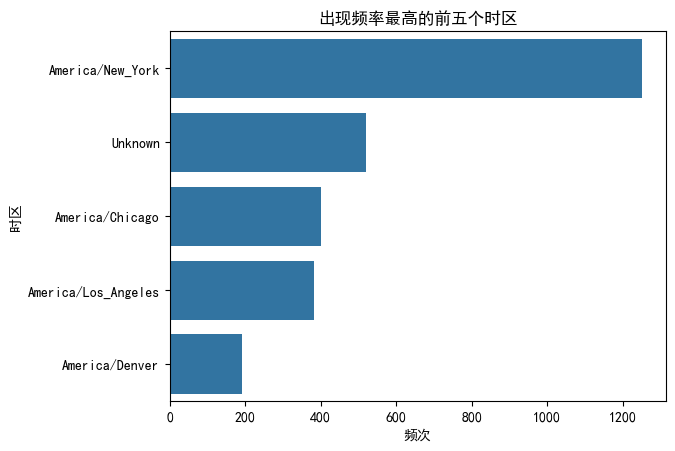

In [85]:
# 用seaborn包（http://seaborn.pydata.org）创建水平柱状图
import seaborn as sns

subset = tz_counts.head()  # 将出现频率最高的五个地区赋给subset

# 绘制条形图
sns.barplot(y=subset.index, x=subset.to_numpy())

plt.title("出现频率最高的前五个时区")
plt.ylabel("时区")
plt.xlabel("频次")

plt.show()

**a 字段包含执行URL短缩操作的浏览器、设备、应用程序的相关信息：**

In [90]:
frame["a"][50]

'Mozilla/5.0 (Windows NT 5.1; rv:10.0.2) Gecko/20100101 Firefox/10.0.2'

In [94]:
frame["a"][51][:50]  # 选取第51行的值，并输出前50个字符

'Mozilla/5.0 (Linux; U; Android 2.2.2; en-us; LG-P9'

将这些“代理”字符串中的所有信息解析出来是一件烦琐的工作。  
一种可能的策略是将这种字符串的第一个标记（与浏览器大致对应）分离出来  
并对用户行为创建另一份概要：

In [100]:
results = pd.Series([x.split()[0] for x in frame["a"].dropna()])

results.head(5)

0               Mozilla/5.0
1    GoogleMaps/RochesterNY
2               Mozilla/4.0
3               Mozilla/5.0
4               Mozilla/5.0
dtype: object

split() 将字符串按分隔符划分成一个列表  
x.split()[0] 选取 x 中的字符串按分隔符生成一个列表后选取第一个元素  
for x in frame["a"].dropna() 剔除"a"列中有空值的行，并循环遍历



前面的输出"a"行中的内容可知，每个字符串应该是按空格分隔的，只需用split将其分开即可，选取第一个，也就是选出其操作的浏览器及其版本这个信息



数据：'Mozilla/5.0  (Windows NT 5.1; rv:10.0.2)  Gecko/20100101  Firefox/10.0.2'  
分割后['Mozilla/5.0', '(Windows', 'NT', '10.0;', 'Win64;', 'x64)']


In [107]:
# 返回所用浏览器最多的前8名
results.value_counts().head(8)

Mozilla/5.0                 2594
Mozilla/4.0                  601
GoogleMaps/RochesterNY       121
Opera/9.80                    34
TEST_INTERNET_AGENT           24
GoogleProducer                21
Mozilla/6.0                    5
BlackBerry8520/5.0.0.681       4
Name: count, dtype: int64

现在，假设你想**按Windows和非Windows用户对TOP时区统计信息进行分解**。  
为了简单起见，我们假定只要代理字符串中含有"Windows"就认为该用户为Windows用户。
由于缺失了部分代理，所以将其从数据中移除：

In [117]:
cframe = frame[frame["a"].notna()].copy()  # 将 a 列中非空值行复制给cframe

# 计算一个值，以确定各行是否为windows
cframe["os"] = np.where(cframe["a"].str.contains("Windows"),  # 添加 os 列，判断是否包含特定字符串
                        "Windows", "Not Windows")
cframe["os"].head(5)

0        Windows
1    Not Windows
2        Windows
3    Not Windows
4        Windows
Name: os, dtype: object

np.where(cframe["a"].str.contains("Windows"), "Windows", "Not Windows") 



**where语句，如果 a 列中包含Windows，则返回Windows，否则返回Not Windows**  



np.where() 是 NumPy 的条件判断函数，格式为 np.where(condition, x, y)，即：当 condition 为 True 时，返回 x，否则返回 y。

In [178]:
# 接下来就可以根据时区列和操作系统列表对数据进行分组了
by_tz_os = cframe.groupby(["tz", "os"])

# 分组计数类似于value_counts函数，可以用size来计算。
agg_counts = by_tz_os.size()  # size返回元素数量
agg_counts.head()

tz                 os         
                   Not Windows    245
                   Windows        276
Africa/Cairo       Windows          3
Africa/Casablanca  Windows          1
Africa/Ceuta       Windows          2
dtype: int64

In [204]:
# 并利用unstack对计数结果进行重塑：
agg_counts = by_tz_os.size().unstack().fillna(0)
agg_counts.head()

os,Not Windows,Windows
tz,,
,245.0,276.0
Africa/Cairo,0.0,3.0
Africa/Casablanca,0.0,1.0
Africa/Ceuta,0.0,2.0
Africa/Johannesburg,0.0,1.0


**unstack()函数是将行索引转换为列索引，并且默认是最底层索引转化为最外层**  
将原先的行索引Windows和Not Windows转化为列索引，并输出每个地区中Windows和Not Windows的出现次数

最后，我们来选取计数最高的所有时区。  
为此，根据agg_counts中的行数构造了一个间接索引数组。    
使用agg_counts.sum（"columns"）计算完行数，可以调用argsort（）获得一个索引数组，用于进行升序排列：

In [206]:
indexer = agg_counts.sum("columns").argsort()

indexer.values[:10]

array([24, 20, 21, 92, 87, 53, 54, 57, 26, 55], dtype=int64)

argsort() 是 NumPy 中的一个函数，用于返回数组元素排序后的索引。也就是说，它不会直接返回排序后的数组，而是返回一个表示元素从小到大排序的索引数组。

In [208]:
# 使用take按顺序选取行，并对最后10行（最大值）进行切片：
count_subset = agg_counts.take(indexer[-10:])  # 选取最后十个元素
count_subset

os,Not Windows,Windows
tz,,
America/Sao_Paulo,13.0,20.0
Europe/Madrid,16.0,19.0
Pacific/Honolulu,0.0,36.0
Asia/Tokyo,2.0,35.0
Europe/London,43.0,31.0
America/Denver,132.0,59.0
America/Los_Angeles,130.0,252.0
America/Chicago,115.0,285.0
,245.0,276.0


In [210]:
# pandas中有一个更便捷的方法 nlargest，它可以完成同样的工作：
agg_counts.sum(axis=1).nlargest(10)  # 前十个最大的值

tz
America/New_York       1251.0
                        521.0
America/Chicago         400.0
America/Los_Angeles     382.0
America/Denver          191.0
Europe/London            74.0
Asia/Tokyo               37.0
Pacific/Honolulu         36.0
Europe/Madrid            35.0
America/Sao_Paulo        33.0
dtype: float64

计算 agg_counts 的行和，然后找到其中前 10 个最大的值  




1. agg_counts.sum(axis=1)：  
agg_counts.sum(axis=1) 计算 agg_counts 中每一行的总和。  
参数 axis=1 指定计算是沿着列的方向进行，即对每一行的所有列数据求和。  
结果是一个 Series，其中每个元素表示 agg_counts 中相应行的总和。



2..nlargest(10)：  
nlargest() 是 Pandas 用于获取前 N 个最大值 的方法。它会根据你指定的数字（这里是 10）从前面的 sum() 结果中提取出值最大的前 10 行。  
返回的是一个包含最大值和对应索引的 Series。

然后，可以使用seaborn的barplot函数，将Windows用户和非Windows用户的数量进行分组比较，绘制成柱状图（见图13-2）。  
为了更兼容于seaborn，我首先调用count_subset.stack（），并重设索引I以重排数据：

In [212]:
count_subset = count_subset.stack()
count_subset.name = "total"
count_subset = count_subset.reset_index()
count_subset.head(10)

,tz,os,total
0,America/Sao_Paulo,Not Windows,13.0
1,America/Sao_Paulo,Windows,20.0
2,Europe/Madrid,Not Windows,16.0
3,Europe/Madrid,Windows,19.0
4,Pacific/Honolulu,Not Windows,0.0
5,Pacific/Honolulu,Windows,36.0
6,Asia/Tokyo,Not Windows,2.0
7,Asia/Tokyo,Windows,35.0
8,Europe/London,Not Windows,43.0
9,Europe/London,Windows,31.0


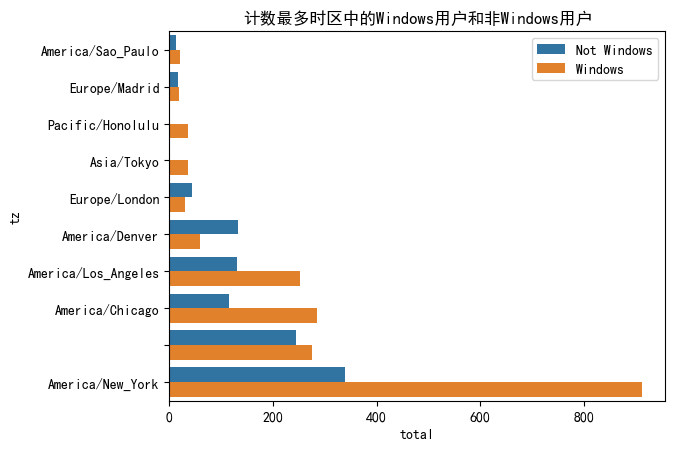

In [218]:
sns.barplot(x="total", y="tz", hue="os", data=count_subset)

plt.title("计数最多时区中的Windows用户和非Windows用户")

plt.legend()

plt.show()

In [220]:
# Windows用户在小分组中的相对比例，因此对分组百分比进行标准化，使其之和为 1：
def norm_total(group):
    group["normed_total"] = group["total"] / group["total"].sum()
    return group

results = count_subset.groupby("tz").apply(norm_total)

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_19468\1265503505.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = count_subset.groupby("tz").apply(norm_total)


警告指出：在未来版本中，apply() 将不再自动对分组列进行操作。为了保持兼容性和避免这个警告，你有两种方法来处理：  
1.使用 include_groups=False  
2.手动选择分组列  

In [225]:
def norm_total(group):
    # 添加新列normal_total，表示组内total归一化的值，每个元素除以total列总和的值
    group["normed_total"] = group["total"] / group["total"].sum()
    return group

# 按照tz进行分组，对分组的每个值运用归一化函数操作赋给results
results = count_subset.groupby("tz").apply(norm_total, include_groups=False)

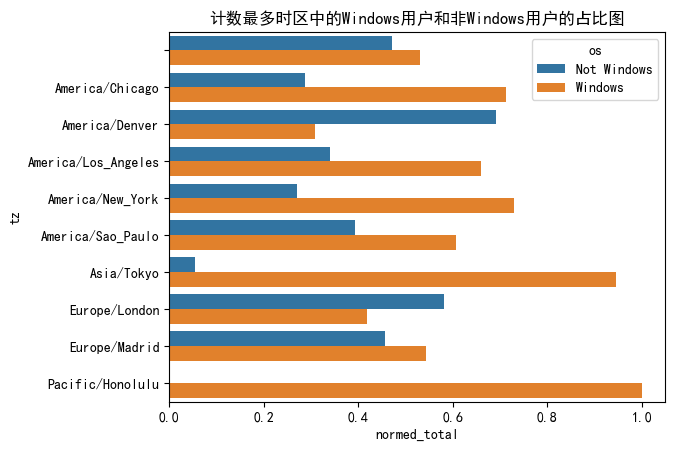

In [229]:
# 使用 os 列作为分类变量，不同操作系统的数据将以不同颜色显示在图表中（比如 Windows 和 Not Windows）。
sns.barplot(x="normed_total", y="tz", hue="os", data=results)

plt.title("计数最多时区中的Windows用户和非Windows用户的占比图")

plt.show()

In [240]:
# 还可以用groupby的transform方法更高效地计算标准化的和：
g = count_subset.groupby("tz")
results1 = count_subset["total"] / g["total"].transform("sum")

transform对每个元素的运算结果必须是一个标量（即与输入的元素数量相同的输出）。常用于在分组内对每个元素应用类似归一化、标准化等操作，并且你希望返回的结果保持原始数据的结构。



归一化用transform很快

In [ ]:
sns.barplot(x="normed_total", y="tz", hue="os", data=results1)

plt.title("计数最多时区中的Windows用户和非Windows用户的占比图")

plt.show()